In [1]:
import sys
import os
# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
import re
import scienceplots
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from modules.utils import plot_actual_vs_predicted, calc_percentage_error, calc_mean_percentage_error, calc_error_factor, calc_r2_score
from modules.capacity_estimation_aus import capacity_estimation_base_load, sensitivity_analysis_irradiance_threshold
# Section:Global variables
my_seed = 42
np.random.seed(my_seed)

# Load data

In [3]:
f_name = '../data/ausgrid/ausgrid_merged_preprocessed.csv'
f_name_pv_capacity = '../data/ausgrid/ausgrid_pv_capacity_from_pv_profiles.csv'
df = pd.read_csv(f_name)
df_pv_capacity = pd.read_csv(f_name_pv_capacity)

In [4]:
f_name1 = '../data/ausgrid/ausgrid_merged_preprocessed_part1.csv'
df_part1 = pd.read_csv(f_name1)
f_name2 = '../data/ausgrid/ausgrid_merged_preprocessed_part2.csv'
df_part2 = pd.read_csv(f_name2)

In [5]:
# rename the first column of df_pv_capacity to 'household', second to 'capacity'
df_pv_capacity.rename(columns={
                      df_pv_capacity.columns[0]: 'household', df_pv_capacity.columns[1]: 'capacity'}, inplace=True)
df_pv_capacity

,household,capacity
0,4,801.924735
1,6,666.676746
2,11,1408.919480
3,12,812.092215
4,16,1983.415300
...,...,...
72,279,1319.625450
73,282,2493.158552
74,288,1314.328443
75,291,844.810546


In [6]:
# split the df_pv_capacity into part 1 and part 2 based on households in each partition
# Find which households are in part1 and part2 by extracting from column names
# Household IDs are columns that end with '_net' (remove the suffix to get the household ID)
# Convert to int since household IDs in df_pv_capacity are integers
# Exclude 'total_net' since it's not a household ID
households_part1 = set([int(col.replace('_net', ''))
                       for col in df_part1.columns if col.endswith('_net') and col != 'total_net'])
households_part2 = set([int(col.replace('_net', ''))
                       for col in df_part2.columns if col.endswith('_net') and col != 'total_net'])

# Filter df_pv_capacity based on which households are in each partition
df_pv_capacity_part1 = df_pv_capacity[df_pv_capacity['household'].isin(
    households_part1)]
df_pv_capacity_part2 = df_pv_capacity[df_pv_capacity['household'].isin(
    households_part2)]

In [7]:
households_to_remove = []
df_pv_capacity = df_pv_capacity[~df_pv_capacity['household'].isin(
    households_to_remove)]

In [8]:
# columns that ends with '_pv'
pv_cols = [col for col in df.columns if col.endswith('_pv')]
# columns that ends with '_con'
con_cols = [col for col in df.columns if col.endswith('_con')]
# columns that ends with '_net'
net_cols = [col for col in df.columns if col.endswith('_net')]

# Check the distribution of ghi

This gives us a rough idea of the thresholds of ghi to use.

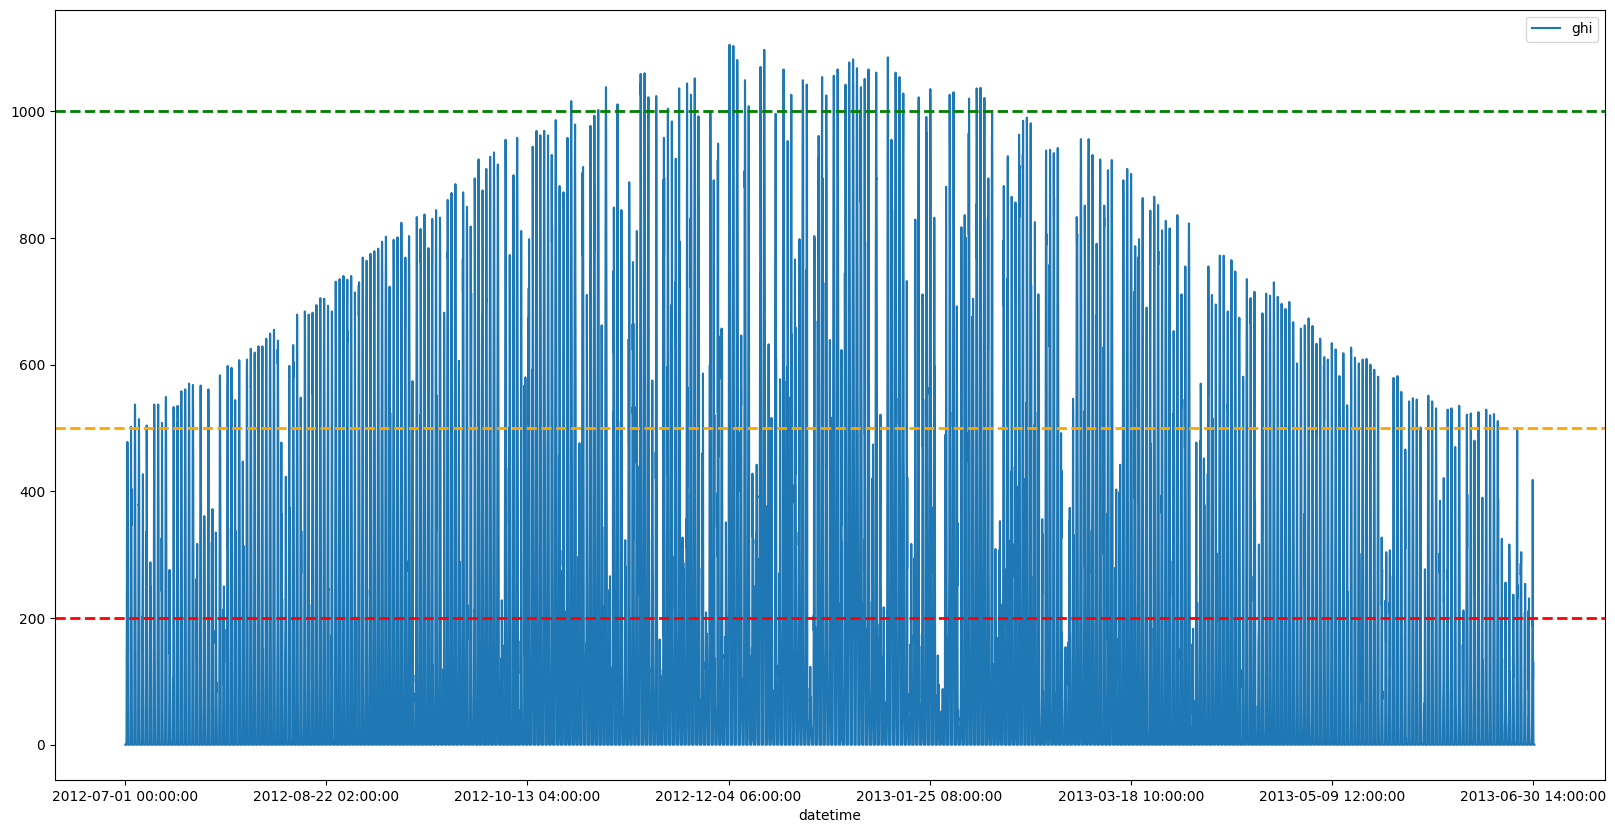

In [9]:
df_part1.plot(x='datetime', y='ghi', figsize=(20, 10))
# draw a line where y=200
plt.axhline(y=200, color='red', linewidth=2, linestyle='--')
# draw a line where y=500
plt.axhline(y=500, color='orange', linewidth=2, linestyle='--')
# draw a line where y=1000
plt.axhline(y=1000, color='green', linewidth=2, linestyle='--')
plt.show()

# Capacity estimation based on base load

## Estimate the capacity for all households

Set the base_load_correction_factor to 1, since there is no historical data to calculate the correction factor.

In [10]:
# remove total_net and households to remove from net_cols
households_to_remove_with_suffix = [
    col + '_net' for col in households_to_remove]
net_cols_without_total_net = [col for col in net_cols if col !=
                              'total_net' and col not in households_to_remove_with_suffix]
# create an instance of capacity_estimation_base_load
cap_est_based_load = capacity_estimation_base_load(
    df, net_cols_without_total_net, base_load_correction_factor=1)
# estimate the capacity
capacity_based_load = cap_est_based_load.estimate_capacity()

In [11]:
capacity_based_load

4_net       827.913045
6_net       727.637605
11_net     1706.471347
12_net      615.117099
16_net     2061.373702
              ...     
279_net    1415.404439
282_net    2777.557569
288_net    1191.288178
291_net    1109.048519
298_net     864.271608
Length: 77, dtype: float64

In [12]:
# the length of capacity_based_load should be the same as df_pv_capacity
len(capacity_based_load)

77

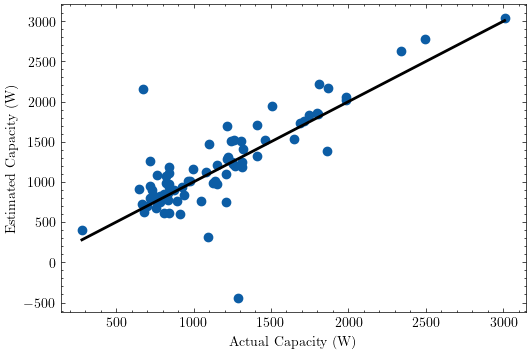

0.4830244811776496

In [13]:
# plot the estimated capacity vs the actual capacity
# the second column of df_pv_capacity is the actual capacity
plot_actual_vs_predicted(df_pv_capacity.iloc[:, 1], capacity_based_load,
                         xlabel='Actual Capacity (W)', ylabel='Estimated Capacity (W)', trendline=False)
# calculate the R2 score
calc_r2_score(df_pv_capacity.iloc[:, 1], capacity_based_load)

In [14]:
# sum up the capacity of all households both real and estimated
real_capacity = df_pv_capacity['capacity'].sum()
estimated_capacity = capacity_based_load.sum()
print(
    f'The real capacity is {real_capacity} W, and the estimated capacity is {estimated_capacity} W')
# print the error rate
capacity_error_rate = (
    real_capacity - estimated_capacity) / real_capacity * 100
print(f'The error rate is {capacity_error_rate}%')
error_factor = real_capacity/estimated_capacity
print(f'The error factor is {error_factor}')

The real capacity is 89867.4014842411 W, and the estimated capacity is 93487.16184856874 W
The error rate is -4.02789031900782%
The error factor is 0.9612806689950546


In [15]:
# save the error rate to a npy file
np.save("../data/ausgrid/capacity_error_rate.npy", capacity_error_rate)
# save the error factor to a npy file
np.save("../data/ausgrid/capacity_error_factor.npy", error_factor)

## Sensitivity analysis

# base_load_correction_factor for two parts

In [16]:
# columns that ends with '_net'
net_cols = [col for col in df_part1.columns if col.endswith('_net')]
# remove total_net and households to remove from net_cols
net_cols_part1 = [col for col in net_cols if col !=
                  'total_net' and col not in households_to_remove_with_suffix]
net_cols_without_total_net_part1 = [
    col for col in net_cols_part1 if col != 'total_net']
cap_est_based_load_part1_tmp = capacity_estimation_base_load(
    df_part1, net_cols_without_total_net_part1)
cap_est_based_load_part1_tmp.estimate_capacity()
base_load_correction_factor_from_part1 = cap_est_based_load_part1_tmp.base_load_correction_factor

In [17]:
# columns that ends with '_net'
net_cols = [col for col in df_part2.columns if col.endswith('_net')]
# remove total_net and households to remove from net_cols
net_cols_part2 = [col for col in net_cols if col !=
                  'total_net' and col not in households_to_remove_with_suffix]
net_cols_without_total_net_part2 = [
    col for col in net_cols_part2 if col != 'total_net']
cap_est_based_load_part2_tmp = capacity_estimation_base_load(
    df_part2, net_cols_without_total_net_part2)
cap_est_based_load_part2_tmp.estimate_capacity()
base_load_correction_factor_from_part2 = cap_est_based_load_part2_tmp.base_load_correction_factor

In [18]:
print(
    f'base_load_correction_factor_from_part2: {base_load_correction_factor_from_part2}')

base_load_correction_factor_from_part2: 0.9069150278318008


# Estimation for part 1

In [19]:
# columns that ends with '_net'
net_cols = [col for col in df_part1.columns if col.endswith('_net')]
# create an instance of capacity_estimation_base_load
# remove total_net and households to remove from net_cols
net_cols_part1 = [col for col in net_cols if col !=
                  'total_net' and col not in households_to_remove_with_suffix]
net_cols_without_total_net = [
    col for col in net_cols_part1 if col != 'total_net']

cap_est_based_load_part1 = capacity_estimation_base_load(
    df_part1, net_cols_without_total_net, base_load_correction_factor=base_load_correction_factor_from_part2)
# cap_est_based_load_part1 = capacity_estimation_base_load(df_part1,net_cols_without_total_net,base_load_correction_factor=1)
capacity_based_load_part1 = cap_est_based_load_part1.estimate_capacity()
capacity_based_load_part1

53_net     1617.013475
12_net      532.414874
129_net     804.795096
118_net    1225.887113
105_net     899.987767
60_net     1778.249701
48_net     1694.782328
275_net    1014.400204
44_net      848.175258
213_net    1450.118400
16_net     1951.845048
291_net    1024.261171
268_net    1861.683960
99_net      730.735942
298_net     817.248074
120_net    1487.567155
139_net    1111.305498
6_net       602.900378
288_net    1132.474465
45_net     1204.904874
172_net     720.539911
156_net    1075.950556
164_net    1147.835741
128_net     247.873512
98_net      715.210436
242_net     719.591989
279_net    1299.153481
135_net    1168.428508
278_net     975.886734
4_net       776.783876
43_net      724.047843
264_net     747.849571
244_net    1658.378414
78_net     1932.327325
182_net    1438.693129
40_net      629.850668
277_net     550.576235
162_net     778.850615
31_net     1213.821380
dtype: float64

In [20]:
df_pv_capacity_part1

,household,capacity
0,4,801.924735
1,6,666.676746
3,12,812.092215
4,16,1983.415300
6,31,1218.275705
9,40,758.526738
10,43,1046.385680
11,44,649.284132
12,45,1311.863320
13,48,1710.361486


In [21]:
# convert capacity_based_load_part1 to a dataframe, aligning with df_pv_capacity_part1
# First, extract household IDs from the index and convert to int
household_ids_from_capacity = [
    int(col.replace('_net', '')) for col in capacity_based_load_part1.index]
df_capacity_based_load_part1 = pd.DataFrame({
    'household': household_ids_from_capacity,
    'estimated_capacity': capacity_based_load_part1.values
})

# Merge with df_pv_capacity_part1 based on household ID
df_pv_capacity_part1 = df_pv_capacity_part1.merge(
    df_capacity_based_load_part1, on='household', how='left')
df_pv_capacity_part1

,household,capacity,estimated_capacity
0,4,801.924735,776.783876
1,6,666.676746,602.900378
2,12,812.092215,532.414874
3,16,1983.415300,1951.845048
4,31,1218.275705,1213.821380
5,40,758.526738,629.850668
6,43,1046.385680,724.047843
7,44,649.284132,848.175258
8,45,1311.863320,1204.904874
9,48,1710.361486,1694.782328


In [22]:
# Order df_pv_capacity_part1 to match the order of capacity_based_load_part1
# Extract the household IDs from capacity_based_load_part1 in the same order
household_ids_from_capacity = [
    int(col.replace('_net', '')) for col in capacity_based_load_part1.index]
df_pv_capacity_part1 = df_pv_capacity_part1.set_index(
    'household').reindex(household_ids_from_capacity).reset_index()
df_pv_capacity_part1

,household,capacity,estimated_capacity
0,53,1215.696050,1617.013475
1,12,812.092215,532.414874
2,129,874.129030,804.795096
3,118,1225.089051,1225.887113
4,105,823.227289,899.987767
5,60,1744.157880,1778.249701
6,48,1710.361486,1694.782328
7,275,1211.076137,1014.400204
8,44,649.284132,848.175258
9,213,1459.303703,1450.118400


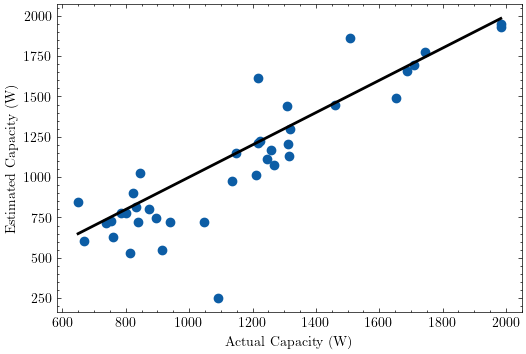

0.6535124710466356

In [23]:
# plot the estimated capacity vs the actual capacity
plot_actual_vs_predicted(df_pv_capacity_part1['capacity'], df_pv_capacity_part1['estimated_capacity'], fig_name='../figs/actual_vs_predicted_capacity_part1_ausgrid.pdf',
                         xlabel='Actual Capacity (W)', ylabel='Estimated Capacity (W)', trendline=False)
# calculate the R2 score
calc_r2_score(df_pv_capacity_part1['capacity'],
              df_pv_capacity_part1['estimated_capacity'])

In [24]:
# sum up the capacity of all households both real and estimated
real_capacity_part1 = df_pv_capacity_part1['capacity'].to_numpy()
estimated_capacity_part1 = df_pv_capacity_part1['estimated_capacity'].to_numpy(
)
real_capacity_part1_sum = df_pv_capacity_part1['capacity'].sum()
estimated_capacity_part1_sum = df_pv_capacity_part1['estimated_capacity'].sum()
print(
    f'The real capacity is {real_capacity_part1_sum} W, and the estimated capacity is {estimated_capacity_part1_sum} W')
PE_part1 = calc_percentage_error(real_capacity_part1, estimated_capacity_part1)
print(f'The percentage error is {PE_part1}%')
MPE_part1 = calc_mean_percentage_error(
    real_capacity_part1, estimated_capacity_part1)
print(f'The mean percentage error is {MPE_part1}%')
R2_part1 = calc_r2_score(real_capacity_part1, estimated_capacity_part1)
print(f'The R2 score is {R2_part1}')
error_factor_part1 = calc_error_factor(
    real_capacity_part1_sum, estimated_capacity_part1_sum)
print(f'The error factor is {error_factor_part1}')

The real capacity is 44973.06047901924 W, and the estimated capacity is 42312.400704676205 W
The percentage error is 5.916118996580806%
The mean percentage error is 6.605601944791937%
The R2 score is 0.6535124710466356
The error factor is 1.0628813239152604


In [25]:
# save the error rate and error factor to npy files
np.save("../data/ausgrid/capacity_error_rate_part1.npy", PE_part1)
np.save("../data/ausgrid/capacity_error_factor_part1.npy", error_factor_part1)

## SA for part 1

In [26]:
df_part1_cleaned = df_part1.drop(columns=[])

In [27]:
# 3 levels of availability, 1 month (2018-06), 3 months(2018-06-2018-08), and 6 months(2018-06-2018-11)
df_part1_1month_summer = df_part1_cleaned[(
    df_part1_cleaned['datetime'] >= '2018-06-01') & (df_part1_cleaned['datetime'] <= '2018-06-30')]
df_part1_1month_winter = df_part1_cleaned[(
    df_part1_cleaned['datetime'] >= '2018-12-01') & (df_part1_cleaned['datetime'] <= '2018-12-31')]
df_part1_3months = df_part1_cleaned[(
    df_part1_cleaned['datetime'] >= '2018-06-01') & (df_part1_cleaned['datetime'] <= '2018-08-31')]
df_part1_6months = df_part1_cleaned[(
    df_part1_cleaned['datetime'] >= '2018-06-01') & (df_part1_cleaned['datetime'] <= '2018-11-30')]

In [28]:
df_pv_capacity_part1_cleaned = df_pv_capacity_part1[df_pv_capacity_part1['household'] != '1955A']

In [29]:
real_capacity_part1_cleaned = df_pv_capacity_part1_cleaned['capacity'].to_numpy(
)

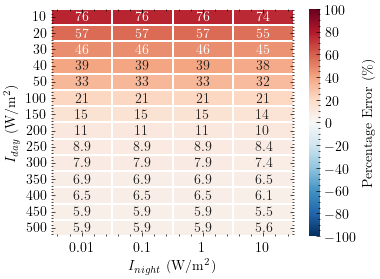

In [30]:
sensitivity_analysis_irradiance_threshold(df_part1, real_capacity_part1_cleaned, fig_name='../figs/sensitivity_analysis_irradiance_threshold_part1.pdf',
                                          base_load_correction_factor=base_load_correction_factor_from_part2)

# Estimation for part 2

In [31]:
df_part2.columns

Index(['56_pv', '194_pv', '62_pv', '192_pv', '251_pv', '131_pv', '32_pv',
       '193_pv', '116_pv', '140_pv',
       ...
       'air_temp_norm', 'precipitation_rate_norm', 'wind_speed_10m_norm',
       'ghi_norm', 'ghi_loc2_norm', 'ghi_loc3_norm', 'azimuth_norm',
       'zenith_norm', 'cos_HoD_norm', 'sin_HoD_norm'],
      dtype='object', length=147)

In [32]:
# columns that ends with '_net'
net_cols = [col for col in df_part2.columns if col.endswith('_net')]
# remove total_net and households to remove from net_cols
net_cols_part2 = [col for col in net_cols if col !=
                  'total_net' and col not in households_to_remove_with_suffix]
net_cols_without_total_net = [
    col for col in net_cols_part2 if col != 'total_net']
cap_est_based_load_part2 = capacity_estimation_base_load(
    df_part2, net_cols_without_total_net, base_load_correction_factor=base_load_correction_factor_from_part1)
capacity_based_load_part2 = cap_est_based_load_part2.estimate_capacity()
capacity_based_load_part2

56_net     1320.269185
194_net    1472.579852
62_net     -454.972068
192_net    1252.976326
251_net    2150.565617
131_net    1067.333425
32_net     1008.681544
193_net    3029.224228
116_net     699.059372
140_net     940.978491
36_net      942.782248
96_net      620.889845
233_net     978.482584
219_net     749.381318
79_net     1081.976696
173_net    2625.361399
159_net    1373.988482
92_net      392.798984
142_net    2168.957713
257_net     851.011511
199_net     899.197298
17_net      741.475502
66_net     1126.040237
205_net    1858.580042
55_net     2206.755117
234_net    1174.964442
217_net     975.073217
220_net    1843.909000
181_net    1161.228395
113_net    1508.403920
126_net    1013.304591
282_net    2774.178401
262_net     933.956170
80_net      614.215066
226_net    1521.399512
71_net      986.117985
11_net     1700.779811
237_net     799.846999
dtype: float64

In [33]:
# convert capacity_based_load_part2 to a dataframe, aligning with df_pv_capacity_part2
# First, extract household IDs from the index and convert to int
household_ids_from_capacity = [
    int(col.replace('_net', '')) for col in capacity_based_load_part2.index]
df_capacity_based_load_part2 = pd.DataFrame({
    'household': household_ids_from_capacity,
    'estimated_capacity': capacity_based_load_part2.values
})

# Merge with df_pv_capacity_part2 based on household ID
df_pv_capacity_part2 = df_pv_capacity_part2.merge(
    df_capacity_based_load_part2, on='household', how='left')

# Order df_pv_capacity_part2 to match the order of capacity_based_load_part2
household_ids_from_capacity = [
    int(col.replace('_net', '')) for col in capacity_based_load_part2.index]
df_pv_capacity_part2 = df_pv_capacity_part2.set_index(
    'household').reindex(household_ids_from_capacity).reset_index()
# for any value that is less than 0, set it to 0
df_pv_capacity_part2['estimated_capacity'] = df_pv_capacity_part2['estimated_capacity'].clip(
    lower=0)
df_pv_capacity_part2

,household,capacity,estimated_capacity
0,56,1408.148105,1320.269185
1,194,1100.346925,1472.579852
2,62,1286.535574,0.000000
3,192,717.275504,1252.976326
4,251,674.188844,2150.565617
5,131,822.515882,1067.333425
6,32,976.609045,1008.681544
7,193,3007.436114,3029.224228
8,116,701.697255,699.059372
9,140,840.928756,940.978491


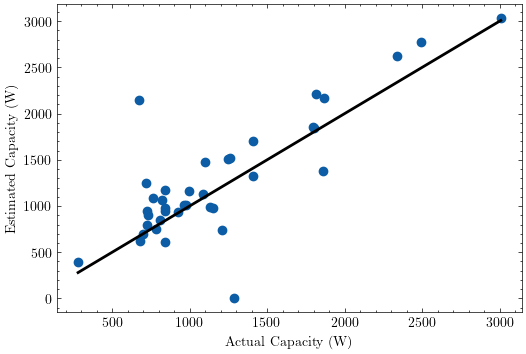

0.5200336316846775

In [34]:
# plot the estimated capacity vs the actual capacity
plot_actual_vs_predicted(df_pv_capacity_part2['capacity'], df_pv_capacity_part2['estimated_capacity'], fig_name='../figs/actual_vs_predicted_capacity_part2_ausgrid.pdf',
                         xlabel='Actual Capacity (W)', ylabel='Estimated Capacity (W)', trendline=False)
calc_r2_score(df_pv_capacity_part2['capacity'],
              df_pv_capacity_part2['estimated_capacity'])

The capacity of household 62 is under estimated. The reason might be that the consumption of this household has very sharp changes. There is no need to do anything extra with it, because we care the total estimated capacity. The bad estimation of household 62 will be averaged out when summing up the capacity of all households.

In [35]:
# sum up the capacity of all households both real and estimated
real_capacity_part2 = df_pv_capacity_part2['capacity'].to_numpy()
estimated_capacity_part2 = df_pv_capacity_part2['estimated_capacity'].to_numpy(
)
real_capacity_part2_sum = df_pv_capacity_part2['capacity'].sum()
estimated_capacity_part2_sum = df_pv_capacity_part2['estimated_capacity'].sum()
print(
    f'The real capacity is {real_capacity_part2_sum} W, and the estimated capacity is {estimated_capacity_part2_sum} W')
PE_part2 = calc_percentage_error(real_capacity_part2, estimated_capacity_part2)
print(f'The percentage error is {PE_part2}%')
MPE_part2 = calc_mean_percentage_error(
    real_capacity_part2, estimated_capacity_part2)
print(f'The mean percentage error is {MPE_part2}%')
R2_part2 = calc_r2_score(real_capacity_part2, estimated_capacity_part2)
print(f'The R2 score is {R2_part2}')
error_factor_part2 = calc_error_factor(
    real_capacity_part2_sum, estimated_capacity_part2_sum)
print(f'The error factor is {error_factor_part2}')

The real capacity is 44894.341005221875 W, and the estimated capacity is 48566.724524153855 W
The percentage error is -8.18005885976771%
The mean percentage error is -13.105003862190326%
The R2 score is 0.5200336316846775
The error factor is 0.9243847808368139


In [36]:
# save the the error rate and error factor to npy files
np.save("../data/ausgrid/capacity_error_rate_part2.npy",
        PE_part2)
np.save("../data/ausgrid/capacity_error_factor_part2.npy", error_factor_part2)

## SA for part 2

In [37]:
real_capacity_part2 = df_pv_capacity_part2['capacity'].to_numpy()

In [38]:
df_part2_1month_summer = df_part2[(
    df_part2['datetime'] >= '2018-06-01') & (df_part2['datetime'] <= '2018-06-30')]
df_part2_1month_winter = df_part2[(
    df_part2['datetime'] >= '2018-12-01') & (df_part2['datetime'] <= '2018-12-31')]
df_part2_3months = df_part2[(
    df_part2['datetime'] >= '2018-06-01') & (df_part2['datetime'] <= '2018-08-31')]
df_part2_6months = df_part2[(
    df_part2['datetime'] >= '2018-06-01') & (df_part2['datetime'] <= '2018-11-30')]

In [39]:
df_pv_capacity_part2_cleaned = df_pv_capacity_part2[df_pv_capacity_part2['household'] != '1955A']
real_capacity_part2_cleaned = df_pv_capacity_part2_cleaned['capacity'].to_numpy(
)

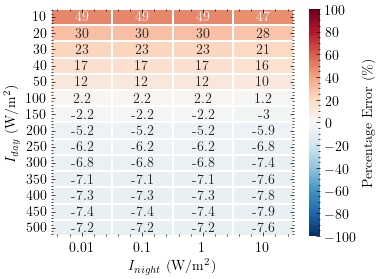

In [40]:
sensitivity_analysis_irradiance_threshold(df_part2, real_capacity_part2_cleaned, fig_name='../figs/sensitivity_analysis_irradiance_threshold_part2.pdf',
                                          base_load_correction_factor=base_load_correction_factor_from_part1)